# Root vs MRCA vs Earliest Tip

Track how location matching changes with increasing migration rate.

In [2]:
import re, glob, dendropy, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

DATASETS = [
    "/Users/lukelyu/Desktop/epidata/500_1_0.001",
    "/Users/lukelyu/Desktop/epidata/500_1_0.002",
    "/Users/lukelyu/Desktop/epidata/500_1_0.003",
    "/Users/lukelyu/Desktop/epidata/500_1_0.004",
    "/Users/lukelyu/Desktop/epidata/500_1_0.005",
    "/Users/lukelyu/Desktop/epidata/500_1_0.006",
]
MIGRATION_RATES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006]

In [3]:
def convert_annotation(match):
    text = match.group(0)
    loc = re.search(r'I\{(\d+)\}', text).group(1)
    time = re.search(r'time=([\d.eE+-]+)', text).group(1)
    return f'[&location={loc},time={time}]'

def load_tree(filepath):
    with open(filepath) as f:
        content = f.read()
    tree_str = re.search(r'tree\s+\w+\s*=\s*(.+)', content).group(1)
    converted = re.sub(r'\[&[^\]]+\]', convert_annotation, tree_str)
    tree = dendropy.Tree.get(data=converted, schema="newick", extract_comment_metadata=True)
    tree.is_rooted = True
    return tree

def analyze_tree(filepath):
    tree = load_tree(filepath)
    tips = list(tree.leaf_node_iter())
    
    root = tree.seed_node
    mrca = tree.mrca(taxon_labels=[t.taxon.label for t in tips])
    earliest = min(tips, key=lambda t: float(t.annotations.get_value('time')))
    
    get_loc = lambda n: int(n.annotations.get_value('location'))
    r, m, e = get_loc(root), get_loc(mrca), get_loc(earliest)
    
    return {'root_eq_mrca': r == m, 'mrca_eq_etip': m == e, 'root_eq_etip': r == e}

In [4]:
# Analyze all datasets
summary = []
for folder, rate in zip(DATASETS, MIGRATION_RATES):
    files = sorted(glob.glob(f"{folder}/*_beast2.trees"))
    results = [analyze_tree(f) for f in files]
    df = pd.DataFrame(results)
    n = len(df)
    summary.append({
        'migration_rate': rate,
        'root_eq_mrca': df['root_eq_mrca'].sum() / n * 100,
        'mrca_eq_etip': df['mrca_eq_etip'].sum() / n * 100,
        'root_eq_etip': df['root_eq_etip'].sum() / n * 100,
        'n_trees': n
    })
    print(f"Done: {rate} ({n} trees)")

summary_df = pd.DataFrame(summary)
summary_df

Done: 0.001 (500 trees)
Done: 0.002 (500 trees)
Done: 0.003 (500 trees)
Done: 0.004 (500 trees)
Done: 0.005 (500 trees)
Done: 0.006 (500 trees)


,migration_rate,root_eq_mrca,mrca_eq_etip,root_eq_etip,n_trees
0,0.001,92.4,79.2,73.4,500
1,0.002,82.6,63.4,53.2,500
2,0.003,78.4,56.4,45.0,500
3,0.004,76.2,46.2,35.8,500
4,0.005,67.2,41.2,29.0,500
5,0.006,64.2,39.6,25.2,500


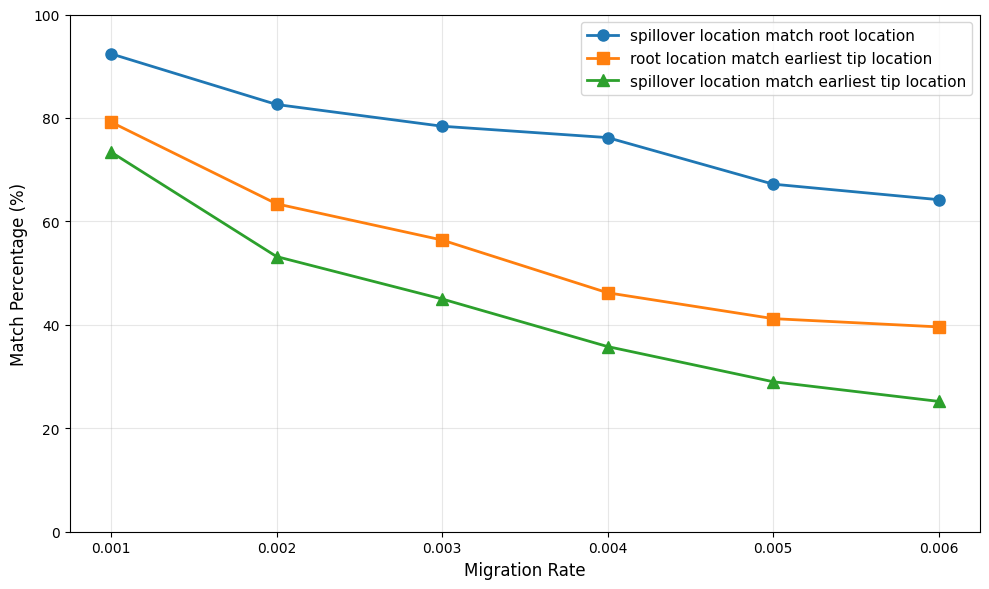

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(summary_df['migration_rate'], summary_df['root_eq_mrca'], 'o-', label='spillover location match root location', linewidth=2, markersize=8)
ax.plot(summary_df['migration_rate'], summary_df['mrca_eq_etip'], 's-', label='root location match earliest tip location', linewidth=2, markersize=8)
ax.plot(summary_df['migration_rate'], summary_df['root_eq_etip'], '^-', label='spillover location match earliest tip location', linewidth=2, markersize=8)

ax.set_xlabel('Migration Rate', fontsize=12)
ax.set_ylabel('Match Percentage (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('rootlabel.pdf')
plt.show()